In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# load data
df_deaths = pd.read_csv('../data/Deaths_1x1.txt', skiprows=2, sep=r'\s+')
df_deaths['Age'] = df_deaths['Age'].replace('110+', 110).astype(int)
df_exposure = pd.read_csv('../data/Exposures_1x1.txt', skiprows=2, sep=r'\s+')
df_exposure['Age'] = df_exposure['Age'].replace('110+', 110).astype(int)

df = df_deaths.merge(df_exposure, on=['Year', 'Age'], suffixes=('_deaths', '_exp'))
df['mx_total'] = df['Total_deaths'] / df['Total_exp']
df = df[(df['Age'] <= 100) & (df['mx_total'] > 0)].copy()
df['log_mx_total'] = np.log(df['mx_total'])
df['log_age'] = np.log1p(df['Age'])
df['age_squared'] = df['Age'] ** 2

train_mask = df['Year'] <= 2000
test_mask = df['Year'] > 2000

print(f"Data loaded: {df.shape}")

Data loaded: (10201, 12)


In [2]:
# ── LEE-CARTER ───────────────────────────────────────────────────────────────
matrix = df.pivot(index='Age', columns='Year', values='mx_total')
ages = matrix.index.values
years = matrix.columns.values
test_years = years[years > 2000]

matrix_train = matrix[matrix.columns[matrix.columns <= 2000]]
log_mx_train = np.log(matrix_train.values)
years_train = matrix_train.columns.values

alpha_lc = log_mx_train.mean(axis=1)
centred = log_mx_train - alpha_lc[:, np.newaxis]
U, S, Vt = np.linalg.svd(centred)
beta_lc = U[:, 0] / U[:, 0].sum()
kappa_lc = Vt[0, :] * S[0] * U[:, 0].sum()

post1950 = years_train >= 1950
lr_lc = LinearRegression()
lr_lc.fit(years_train[post1950].reshape(-1, 1), kappa_lc[post1950])
kappa_fore = lr_lc.predict(test_years.reshape(-1, 1))

# build full LC prediction array indexed by age and year
lc_preds = {}
for i, yr in enumerate(test_years):
    for j, age in enumerate(ages):
        lc_preds[(age, yr)] = alpha_lc[j] + beta_lc[j] * kappa_fore[i]

print("Lee-Carter fitted")

Lee-Carter fitted


In [3]:
# ── NEURAL NETWORK ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

features = ['Age', 'Year', 'log_age', 'age_squared']
X = df[features].values
y = df['log_mx_total'].values
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_ages_col = df[test_mask]['Age'].values
test_years_col = df[test_mask]['Year'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled)

class MortalityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x).squeeze()

model_nn = MortalityNet()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
criterion = nn.MSELoss()
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

for epoch in range(1000):
    model_nn.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        criterion(model_nn(X_batch), y_batch).backward()
        optimizer.step()

model_nn.eval()
with torch.no_grad():
    nn_preds_arr = model_nn(X_test_t).numpy()

# build nn prediction lookup
nn_preds = {}
for i, (age, yr) in enumerate(zip(test_ages_col, test_years_col)):
    nn_preds[(age, yr)] = nn_preds_arr[i]

print("Neural Network fitted")

Neural Network fitted


In [5]:
# ── HYBRID MODELS ────────────────────────────────────────────────────────────
def sigmoid_weight(age, cutoff, steepness=0.3):
    """weight for neural net — 0 at young ages, 1 at old ages"""
    return 1 / (1 + np.exp(-steepness * (age - cutoff)))

cutoffs = [35, 40, 45, 55]
hybrid_results = {}

for cutoff in cutoffs:
    actual_list, predicted_list = [], []
    
    for age, yr in zip(test_ages_col, test_years_col):
        w_nn = sigmoid_weight(age, cutoff)
        w_lc = 1 - w_nn
        
        pred = w_lc * lc_preds[(age, yr)] + w_nn * nn_preds[(age, yr)]
        actual_list.append(y_test[list(zip(test_ages_col, test_years_col)).index((age, yr))])
        predicted_list.append(pred)
    
    actual_arr = np.array(actual_list)
    pred_arr = np.array(predicted_list)
    
    mae = mean_absolute_error(actual_arr, pred_arr)
    rmse = np.sqrt(mean_squared_error(actual_arr, pred_arr))
    hybrid_results[cutoff] = {'mae': mae, 'rmse': rmse, 'preds': pred_arr}
    print(f"Hybrid (cutoff={cutoff}) — MAE: {mae:.4f}  RMSE: {rmse:.4f}")

print()
print("Benchmarks:")
print(f"Lee-Carter   — MAE: 0.2367  RMSE: 0.2896")
print(f"Neural Net   — MAE: 0.1769  RMSE: 0.2679")

Hybrid (cutoff=35) — MAE: 0.1025  RMSE: 0.1568
Hybrid (cutoff=40) — MAE: 0.1001  RMSE: 0.1539
Hybrid (cutoff=45) — MAE: 0.1037  RMSE: 0.1567
Hybrid (cutoff=55) — MAE: 0.1205  RMSE: 0.1687

Benchmarks:
Lee-Carter   — MAE: 0.2367  RMSE: 0.2896
Neural Net   — MAE: 0.1769  RMSE: 0.2679


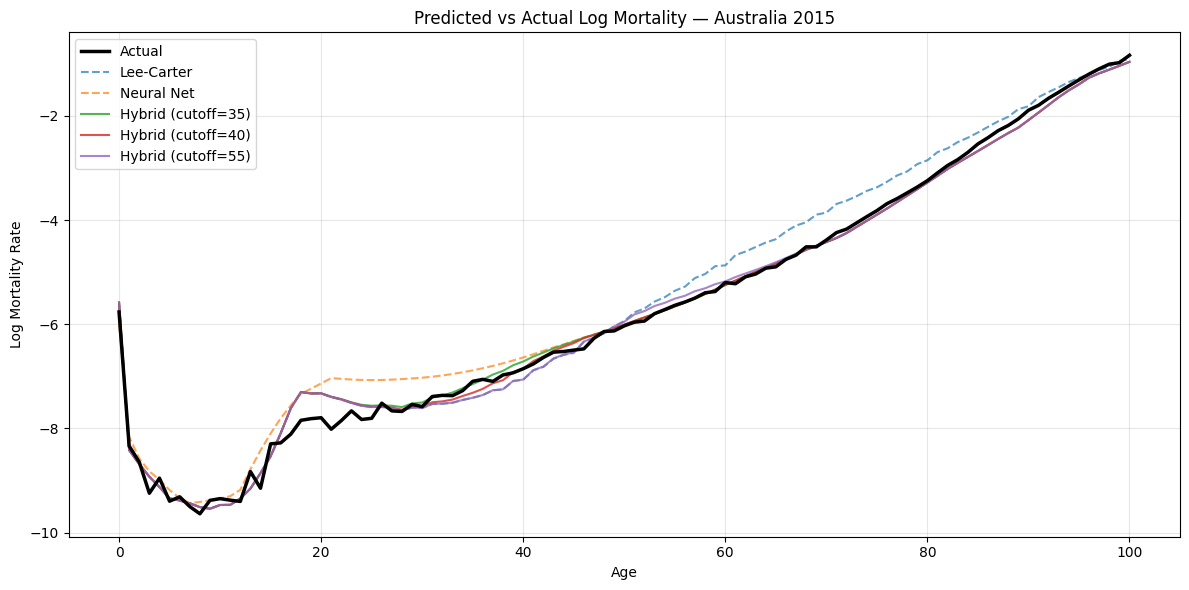

In [7]:
yr = 2015
ages_plot = np.arange(0, 101)

# actual
actual_2015 = df[df['Year'] == yr].sort_values('Age')['log_mx_total'].values

# lee-carter
yr_idx = np.where(test_years == yr)[0][0]
lc_2015 = np.array([lc_preds[(age, yr)] for age in ages_plot])

# neural net
X_2015 = np.column_stack([
    ages_plot,
    np.full(101, yr),
    np.log1p(ages_plot),
    ages_plot ** 2
])
X_2015_scaled = scaler.transform(X_2015)
model_nn.eval()
with torch.no_grad():
    nn_2015 = model_nn(torch.FloatTensor(X_2015_scaled)).numpy()

# hybrids
def hybrid_pred(age, yr, cutoff):
    w_nn = 1 / (1 + np.exp(-0.3 * (age - cutoff)))
    return (1 - w_nn) * lc_preds[(age, yr)] + w_nn * nn_preds[(age, yr)]

hybrid_35 = np.array([hybrid_pred(age, yr, 35) for age in ages_plot])
hybrid_40 = np.array([hybrid_pred(age, yr, 40) for age in ages_plot])
hybrid_55 = np.array([hybrid_pred(age, yr, 55) for age in ages_plot])

plt.figure(figsize=(12, 6))
plt.plot(ages_plot, actual_2015, 'k-', linewidth=2.5, label='Actual', zorder=5)
plt.plot(ages_plot, lc_2015, '--', alpha=0.7, label='Lee-Carter')
plt.plot(ages_plot, nn_2015, '--', alpha=0.7, label='Neural Net')
plt.plot(ages_plot, hybrid_35, '-', alpha=0.8, label='Hybrid (cutoff=35)')
plt.plot(ages_plot, hybrid_40, '-', alpha=0.8, label='Hybrid (cutoff=40)')
plt.plot(ages_plot, hybrid_55, '-', alpha=0.8, label='Hybrid (cutoff=55)')
plt.xlabel('Age')
plt.ylabel('Log Mortality Rate')
plt.title(f'Predicted vs Actual Log Mortality — Australia {yr}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../results/figures/hybrid_weights_and_error_by_age.png'

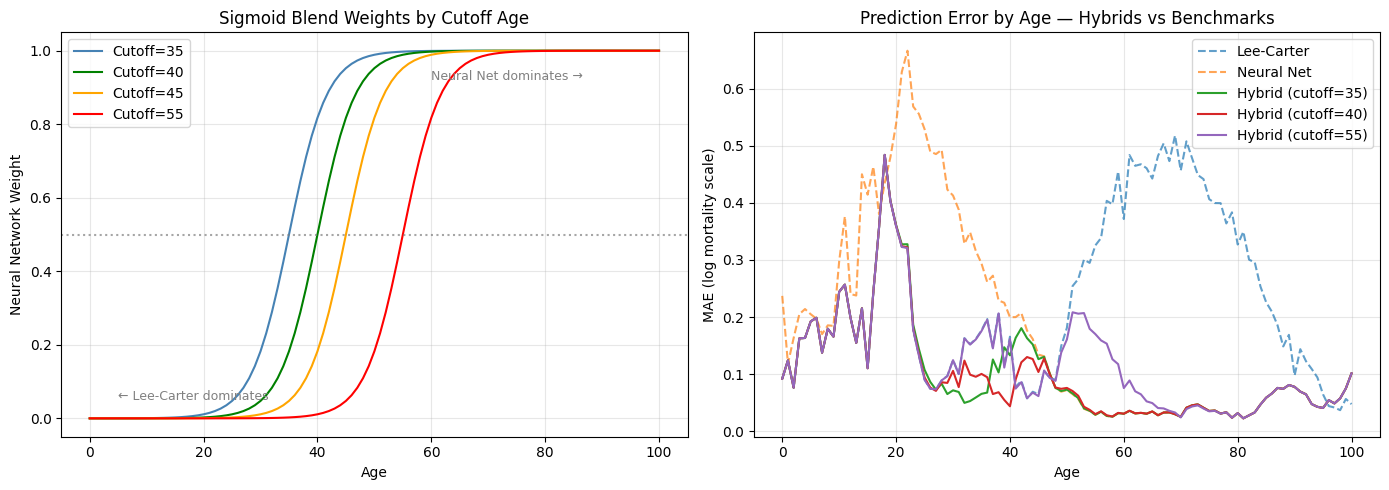

In [ ]:
# ── VISUALISATION 2: SIGMOID WEIGHT CURVES ───────────────────────────────────
ages_plot = np.arange(0, 101)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sigmoid weights
for cutoff, color in zip([35, 40, 45, 55], ['steelblue', 'green', 'orange', 'red']):
    w_nn = 1 / (1 + np.exp(-0.3 * (ages_plot - cutoff)))
    axes[0].plot(ages_plot, w_nn, label=f'Cutoff={cutoff}', color=color)

axes[0].axhline(0.5, color='grey', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Neural Network Weight')
axes[0].set_title('Sigmoid Blend Weights by Cutoff Age')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate('← Lee-Carter dominates', xy=(5, 0.05), fontsize=9, color='grey')
axes[0].annotate('Neural Net dominates →', xy=(60, 0.92), fontsize=9, color='grey')

# error by age for hybrids + benchmarks
test_df = df[df['Year'] > 2000].sort_values(['Age', 'Year'])
test_ages_unique = np.arange(0, 101)

mae_lc_age, mae_nn_age = [], []
mae_h35_age, mae_h40_age, mae_h55_age = [], [], []

for age in test_ages_unique:
    age_data = test_df[test_df['Age'] == age]
    if len(age_data) == 0:
        continue

    actual_age = age_data['log_mx_total'].values
    test_yrs_age = age_data['Year'].values

    lc_age = [lc_preds[(age, yr)] for yr in test_yrs_age]
    nn_age = [nn_preds[(age, yr)] for yr in test_yrs_age]

    def hybrid_age(cutoff):
        w = 1 / (1 + np.exp(-0.3 * (age - cutoff)))
        return [(1 - w) * lc_preds[(age, yr)] + w * nn_preds[(age, yr)] for yr in test_yrs_age]

    mae_lc_age.append(mean_absolute_error(actual_age, lc_age))
    mae_nn_age.append(mean_absolute_error(actual_age, nn_age))
    mae_h35_age.append(mean_absolute_error(actual_age, hybrid_age(35)))
    mae_h40_age.append(mean_absolute_error(actual_age, hybrid_age(40)))
    mae_h55_age.append(mean_absolute_error(actual_age, hybrid_age(55)))

axes[1].plot(test_ages_unique, mae_lc_age, '--', alpha=0.7, label='Lee-Carter')
axes[1].plot(test_ages_unique, mae_nn_age, '--', alpha=0.7, label='Neural Net')
axes[1].plot(test_ages_unique, mae_h35_age, '-', label='Hybrid (cutoff=35)')
axes[1].plot(test_ages_unique, mae_h40_age, '-', label='Hybrid (cutoff=40)')
axes[1].plot(test_ages_unique, mae_h55_age, '-', label='Hybrid (cutoff=55)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('MAE (log mortality scale)')
axes[1].set_title('Prediction Error by Age — Hybrids vs Benchmarks')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()